In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# Load the dataset
import pandas as pd
df = pd.read_csv("alzheimers_disease_data.csv")

# Show first 5 rows
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

Shape of dataset: (2149, 35)

Columns:
 Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

Missing values:
 PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity        

In [ ]:
# Drop unnecessary columns
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1)

df.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


In [ ]:
# Separate features (X) and target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2149, 32)
Target shape: (2149,)


In [ ]:
# Convert categorical columns into numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

print("New feature shape after encoding:", X.shape)

New feature shape after encoding: (2149, 32)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1719, 32)
Testing data shape: (430, 32)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data scaled successfully!")

Data scaled successfully!


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8302325581395349


In [ ]:
# Support Vector Machine
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8325581395348837


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9255813953488372


In [ ]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       277
           1       0.96      0.82      0.89       153

    accuracy                           0.93       430
   macro avg       0.94      0.90      0.92       430
weighted avg       0.93      0.93      0.92       430



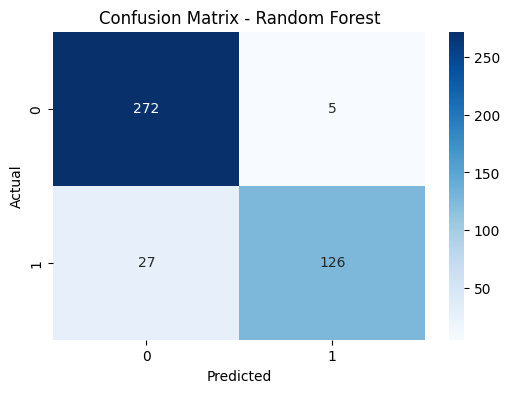

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

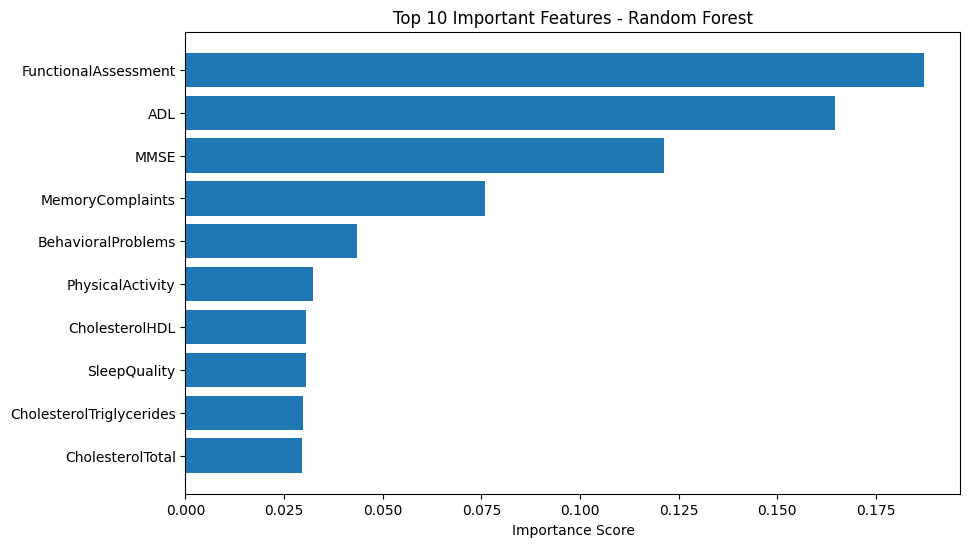

In [ ]:
# Feature Importance - Random Forest

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'][:10],
         feature_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
import joblib

joblib.dump(rf_model, "alzheimers_model.pkl")
print("Model saved successfully!")

Model saved successfully!


Class Distribution:

Diagnosis
0    1389
1     760
Name: count, dtype: int64


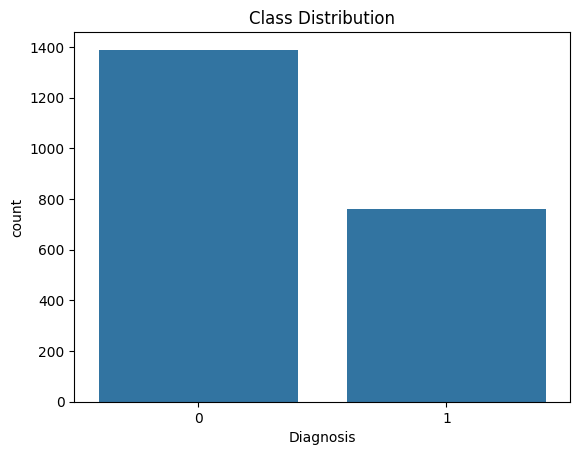

In [ ]:
# Check class distribution
print("Class Distribution:\n")
print(y.value_counts())

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

In [ ]:
class_weight="balanced"

In [ ]:
rf_balanced = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)

y_pred_bal = rf_balanced.predict(X_test)

print("Balanced RF Accuracy:",
      accuracy_score(y_test, y_pred_bal))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bal))

Balanced RF Accuracy: 0.9209302325581395

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       277
           1       0.96      0.81      0.88       153

    accuracy                           0.92       430
   macro avg       0.93      0.90      0.91       430
weighted avg       0.92      0.92      0.92       430



In [ ]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(rf_cv, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.97209302 0.96511628 0.96046512 0.9627907  0.7972028 ]
Mean CV Accuracy: 0.9315335826963734


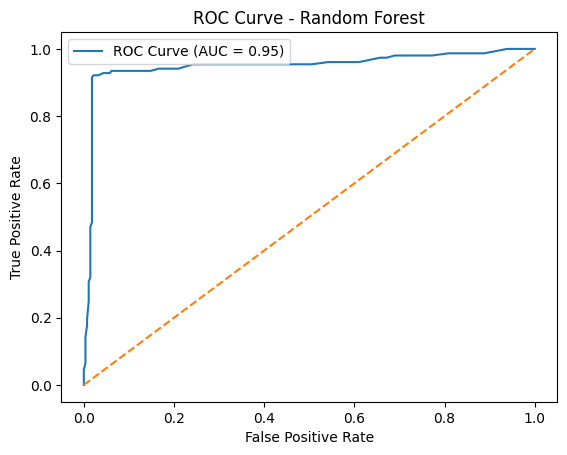

AUC Score: 0.9499185955970837


In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [ ]:
from google.colab import files
files.download("alzheimers_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

print(top_features)

FunctionalAssessment        0.187101
ADL                         0.164764
MMSE                        0.121234
MemoryComplaints            0.075928
BehavioralProblems          0.043380
PhysicalActivity            0.032228
CholesterolHDL              0.030657
SleepQuality                0.030560
CholesterolTriglycerides    0.029869
CholesterolTotal            0.029589
dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
import pandas as pd

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

print(top_features)

FunctionalAssessment        0.187101
ADL                         0.164764
MMSE                        0.121234
MemoryComplaints            0.075928
BehavioralProblems          0.043380
PhysicalActivity            0.032228
CholesterolHDL              0.030657
SleepQuality                0.030560
CholesterolTriglycerides    0.029869
CholesterolTotal            0.029589
dtype: float64


In [ ]:
top_feature_names = top_features.index.tolist()

X_small = X[top_feature_names]

from sklearn.model_selection import train_test_split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_small, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_small = RandomForestClassifier(random_state=42)
rf_small.fit(X_train_s, y_train_s)

print("New Model Accuracy:",
      rf_small.score(X_test_s, y_test_s))

New Model Accuracy: 0.9488372093023256


In [ ]:
import joblib

joblib.dump(rf_small, "alzheimers_small_model.pkl")

['alzheimers_small_model.pkl']